Best K: 13 with Accuracy: 98.18%


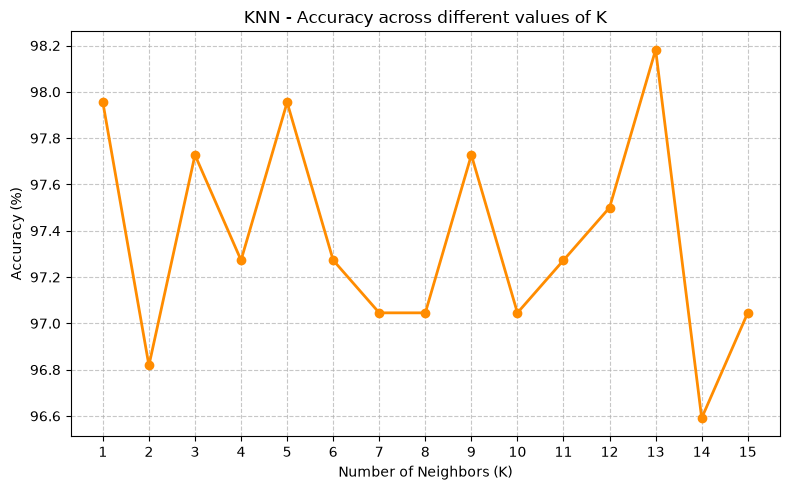

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# 1. โหลดข้อมูล
df = pd.read_csv('crop_fertilizer_recommendation_dataset.csv')
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
target = 'label'

X = df[features]
y = df[target]

# 2. แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. ทดสอบหาค่า K ที่ดีที่สุด และพล็อตกราฟ
k_range = range(1, 16)
scores = []

for k in k_range:
    clf = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    clf.fit(X_train, y_train)
    scores.append(accuracy_score(y_test, clf.predict(X_test)))

print(f"Best K: {k_range[scores.index(max(scores))]} with Accuracy: {max(scores) * 100:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(k_range, [s * 100 for s in scores], marker='o', color='darkorange', linewidth=2)
plt.title('KNN - Accuracy across different values of K')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy (%)')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()